# Dédalo + SRAB — PocketQube Deployment Simulation (LASC 2026)

Complete simulation pipeline for the **Dédalo** rocket (Serra Rocketry) carrying the **Helike #213 PocketQube**,
with apogee deployment and payload descent using the **SRAB (Samara Recovery Wing)** auto-rotation system.

## Overview

| Phase | Vehicle | Method | Description |
|------|---------|--------|-----------|
| **Stage 1** | Full Dédalo (with payload) | RocketPy `Flight` | Ascent to apogee |
| **Stage 2** | Empty Dédalo (no payload) | RocketPy `Flight` + `initial_solution` | Descent under parachute |
| **Stage 3** | PocketQube (payload) | `SRABRecovery.simulate_from_flight()` | Auto-rotating SRAB wing descent |

| Parameter | Value |
|-----------|-------|
| **Rocket** | Dédalo (Serra Rocketry/UERJ), 106 mm dia., 5.35 kg |
| **Motor** | Amateur solid motor (926 N peak, 3.21 s burn) |
| **Payload** | PocketQube 1P (~200 g) |
| **Parachute** | CdS=1.5, apogee trigger |
| **SRAB** | Asa3.DXF, 2 wings, β=5° |
| **Launch site** | Iacanga-SP (SLR), Brazil (21.9430528, -48.9540861), 478 m ASL |

**References:**

- [RocketPy Deployable Payload](https://docs.rocketpy.org/en/latest/user/deployable.html)

- SRAB model: `samara_pq_simulation.py` (`src/` tree)

- Helike #213 mission — LASC 2026


## Setup

Imports the dependencies and sets up the project's absolute paths.

The SRAB module lives in `src/` and the geometries in `geometry/`.


In [3]:
import sys, io, os
from pathlib import Path
from datetime import datetime, timedelta
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from rocketpy import Environment, SolidMotor, Rocket, Flight

# ── Caminhos absolutos ─────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath("")).resolve()
WING_SRC = NOTEBOOK_DIR.parent / "src"
DXF_DIR = WING_SRC.parent / "geometry"

sys.path.insert(0, str(WING_SRC))
from rocketpy_samara.srab_recovery import SRABRecovery
from rocketpy_samara.plotting import plot_lrr_dashboard, plot_trajectory_map

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Wing src:     {WING_SRC}")
print(f"DXF dir:      {DXF_DIR}")
print("RocketPy + SRAB modules carregados OK")


Notebook dir: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks
Wing src:     /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/src
DXF dir:      /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/geometry
RocketPy + SRAB modules carregados OK


## 1. Atmospheric Environment

Sets up the launch environment in **Tatuí-SP, Brazil** (Serra Rocketry launch base).

Uses the GFS forecast atmospheric model (real wind data) for the nominal simulation.


In [4]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)
env.set_date(datetime.datetime.now())
env.set_atmospheric_model(type="Forecast", file="GFS")
print(f"Sea-level density: {env.density(0):.3f} kg/m³")
print("Launch date set to: ", env.datetime_date)


/home/vinicius/.platformio/penv/lib64/python3.13/site-packages/rocketpy/environment/tools.py:553: UserWarning: Exact chosen launch time is not available in the provided file, using 2026-09-03 00:00:00 UTC instead.
  warnings.warn(


Sea-level density: 1.180 kg/m³
Launch date set to:  2026-09-03 00:52:32.656349+00:00


## 2. Rocket Motor

Amateur solid motor (Serra Rocketry), thrust curve measured on a static test bench.


Motor data: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/motor.csv
Motor config: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/dedalo_motor.json
Motor created: 132 pontos de empuxo, burn 3.21 s, peak 944 N



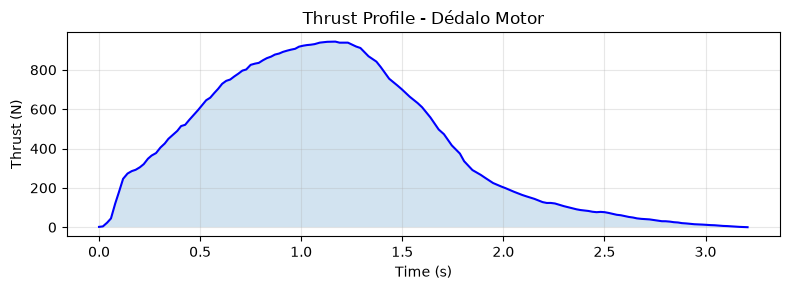

In [5]:
# ── Load motor data ──
MOTOR_CSV = NOTEBOOK_DIR / "motor.csv"
MOTOR_JSON = NOTEBOOK_DIR / "dedalo_motor.json"
print(f"Motor data: {MOTOR_CSV}")
print(f"Motor config: {MOTOR_JSON}")

motor_data = pd.read_csv(MOTOR_CSV)
with open(MOTOR_JSON) as f:
    motor_config = json.load(f)

Dedalo_motor = SolidMotor(
    thrust_source=motor_data,
    dry_mass=motor_config["dry_mass"],
    dry_inertia=motor_config["dry_inertia"],
    nozzle_radius=motor_config["nozzle_radius"],
    grain_number=motor_config["grain_number"],
    grain_density=motor_config["grain_density"],
    grain_outer_radius=motor_config["grain_outer_radius"],
    grain_initial_inner_radius=motor_config["grain_initial_inner_radius"],
    grain_initial_height=motor_config["grain_initial_height"],
    grain_separation=motor_config["grain_separation"],
    grains_center_of_mass_position=motor_config["grains_center_of_mass_position"],
    center_of_dry_mass_position=motor_config["center_of_dry_mass_position"],
    nozzle_position=motor_config["nozzle_position"],
    burn_time=motor_data["Time(s)"].iloc[-1],
    throat_radius=motor_config["throat_radius"],
    coordinate_system_orientation=motor_config["coordinate_system_orientation"],
)

print(f"Motor created: {len(motor_data)} pontos de empuxo, "
      f"burn {motor_data["Time(s)"].iloc[-1]:.2f} s, "
      f"peak {motor_data["Thrust(N)"].max():.0f} N\n")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(motor_data["Time(s)"], motor_data["Thrust(N)"], "b-")
ax.fill_between(motor_data["Time(s)"], motor_data["Thrust(N)"], alpha=0.2)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Thrust (N)")
ax.set_title("Thrust Profile - Dédalo Motor")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Rocket with Payload — Ascent (Stage 1)

Modeling of the full Dédalo (airframe + motor + PocketQube payload).

**Payload:** PocketQube 1P (~110 g), mounted in the payload bay.


> The motor is mounted with the nozzle pointing down (*nozzle_to_combustion_chamber*).

> The rocket uses a *nose_to_tail* coordinate system.


In [6]:
# ── Load rocket data ──
ROCKET_JSON = NOTEBOOK_DIR / "dedalo_data.json"
print(f"Rocket config: {ROCKET_JSON}")
with open(ROCKET_JSON) as f:
    rocket_data = json.load(f)

# ── Drag curves (Cd vs Mach) ──
POWER_OFF_DRAG = NOTEBOOK_DIR / "power_off_drag.csv"
POWER_ON_DRAG  = NOTEBOOK_DIR / "power_on_drag.csv"

print(f"power_off_drag: {POWER_OFF_DRAG}")
print(f"power_on_drag:  {POWER_ON_DRAG}")

# Mass: motorless rocket (from JSON) + PocketQube payload (0.200 kg)
PAYLOAD_MASS = 0.200  # kg (PocketQube 1P)
ROCKET_MASS_NO_MOTOR = rocket_data["mass"]
TOTAL_MASS = ROCKET_MASS_NO_MOTOR + PAYLOAD_MASS

Dedalo_full = Rocket(
    radius=rocket_data["radius"],
    mass=TOTAL_MASS,
    inertia=rocket_data["inertia"],
    power_off_drag=str(POWER_OFF_DRAG),
    power_on_drag=str(POWER_ON_DRAG),
    center_of_mass_without_motor=rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation=rocket_data["coordinate_system_orientation"],
)

# ── Motor ──
Dedalo_full.add_motor(Dedalo_motor, position=1.65)

# ── Nose cone ──
Dedalo_full.add_nose(
    length=rocket_data["nose_length"],
    kind=rocket_data["nose_type"],
    position=rocket_data["nose_position"],
)

# ── Fins ──
Dedalo_full.add_trapezoidal_fins(
    n=rocket_data["n_aletas"],
    root_chord=rocket_data["root_chord"],
    tip_chord=rocket_data["tip_chord"],
    span=rocket_data["span"],
    position=rocket_data["position"],
    cant_angle=rocket_data["cant_angle"],
)

print(f"\nDédalo rocket (with payload) assembled:")
print(f"  Total mass:   {Dedalo_full.mass:.3f} kg ({TOTAL_MASS:.3f} kg config)")
print(f"  Motor mass:   {Dedalo_motor.dry_mass:.3f} kg")
print(f"  Payload:       {PAYLOAD_MASS:.3f} kg (PocketQube 1P)")
print(f"  Diameter:      {Dedalo_full.radius*2000:.0f} mm")


Rocket config: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/dedalo_data.json
power_off_drag: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/power_off_drag.csv
power_on_drag:  /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/power_on_drag.csv

Dédalo rocket (with payload) assembled:
  Total mass:   5.100 kg (5.100 kg config)
  Motor mass:   1.860 kg
  Payload:       0.200 kg (PocketQube 1P)
  Diameter:      106 mm


/home/vinicius/.platformio/penv/lib64/python3.13/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


### 3.1 Ascent Simulation (Stage 1)

Simulation with `terminate_on_apogee=True` to stop automatically at the highest
point of the trajectory. No parachute is needed at this stage — deployment happens
at Stage 2 (empty rocket parachute descent) and Stage 3 (payload SRAB descent).


In [7]:
flight_with_payload = Flight(
    rocket=Dedalo_full,
    environment=env,
    rail_length=4.0,
    inclination=85,
    heading=0,
    terminate_on_apogee=True,
)

print(f"Stage 1 - Dédalo ascent (with payload):")
print(f"  Apogee:         {flight_with_payload.apogee - env.elevation:.0f} m AGL, "
      f"{flight_with_payload.apogee:.0f} m ASL")
print(f"  Time to apogee:   {flight_with_payload.apogee_time:.2f} s")
print(f"  Max speed:       {flight_with_payload.max_speed:.1f} m/s "
      f"({flight_with_payload.max_mach_number:.2f} Mach)")
print(f"  Max accel:      {flight_with_payload.max_acceleration:.1f} m/s² "
      f"({flight_with_payload.max_acceleration/9.80665:.1f} G)")
print(f"  Rail exit:   {flight_with_payload.out_of_rail_time:.2f} s, "
      f"{flight_with_payload.out_of_rail_velocity:.1f} m/s")
print(f"  Impact (no parachute): x={flight_with_payload.x_impact:.1f}, "
      f"y={flight_with_payload.y_impact:.1f} m")


Stage 1 - Dédalo ascent (with payload):
  Apogee:         934 m AGL, 1410 m ASL
  Time to apogee:   14.26 s
  Max speed:       137.4 m/s (0.40 Mach)
  Max accel:      113.3 m/s² (11.6 G)
  Rail exit:   0.57 s, 21.3 m/s
  Impact (no parachute): x=0.0, y=0.0 m


## 4. Rocket without Payload — Parachute Descent (Stage 2)

After the payload is deployed at apogee, the rocket (now lighter) returns
under a traditional parachute. The simulation continues from the final conditions
of Stage 1 (apogee).


In [8]:
# ── Rocket without payload (descent) ──
Dedalo_empty = Rocket(
    radius=rocket_data["radius"],
    mass=ROCKET_MASS_NO_MOTOR,
    inertia=rocket_data["inertia"],
    power_off_drag=str(POWER_OFF_DRAG),
    power_on_drag=str(POWER_ON_DRAG),
    center_of_mass_without_motor=rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation=rocket_data["coordinate_system_orientation"],
)
Dedalo_empty.add_motor(Dedalo_motor, position=1.65)
Dedalo_empty.add_nose(
    length=rocket_data["nose_length"],
    kind=rocket_data["nose_type"],
    position=rocket_data["nose_position"],
)
Dedalo_empty.add_trapezoidal_fins(
    n=rocket_data["n_aletas"],
    root_chord=rocket_data["root_chord"],
    tip_chord=rocket_data["tip_chord"],
    span=rocket_data["span"],
    position=rocket_data["position"],
    cant_angle=rocket_data["cant_angle"],
)

# ── Parachute (apogee trigger via vz < 0) ──
def apogee_acc_trigger(_pressure, _height, state_vector, u_dot):
    vz = state_vector[5]
    az = u_dot[5]
    return abs(vz) < 1.0 and az < -0.1

Dedalo_empty.add_parachute(
    name="main",
    cd_s=1.5,
    trigger=apogee_acc_trigger, 
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)

<Parachute main (cd_s = 1.5000 m2, trigger = <function apogee_acc_trigger at 0x7d47156a2840>)>

In [9]:
flight_without_payload = Flight(
    rocket=Dedalo_empty,
    environment=env,
    rail_length=4.0,
    inclination=85,
    heading=0,
    initial_solution=flight_with_payload,
)

print(f"Stage 2 - Empty Dédalo descent (under parachute):")
print(f"  Apogee:         {flight_without_payload.apogee - env.elevation:.0f} m AGL")
print(f"  Max speed:       {flight_without_payload.max_speed:.1f} m/s "
      f"({flight_without_payload.max_mach_number:.2f} Mach)")
print(f"  Impacto:        x={flight_without_payload.x_impact:.1f}, "
      f"y={flight_without_payload.y_impact:.1f} m")
print(f"  Total time:    {flight_without_payload.t_final:.1f} s")


Stage 2 - Empty Dédalo descent (under parachute):
  Apogee:         934 m AGL
  Max speed:       16.1 m/s (0.05 Mach)
  Impacto:        x=-503.1, y=524.3 m
  Total time:    118.2 s


## 5. PocketQube Payload — SRAB Descent (Stage 3)

The payload (PocketQube) does not use a conventional parachute. Instead,
it uses **SRAB (Samara Recovery Wing)** wings — bio-inspired by samara seeds,
generating stabilized auto-rotation during descent, reducing the impact
velocity to safe levels (< 13.3 m/s with a 1.5 safety factor).

### Wing Parameters

| Parameter | Value |
|-----------|-------|
| **Geometry** | Asa3.DXF (2 symmetric wings) |
| **Coning angle (β)** | 5° |
| **Payload mass** | 200 g |
| **Max allowable velocity** | 20 m/s (LASC) → 13.3 m/s w/ FS 1.5 |


In [10]:
# ── Load wing geometry ──
from samara_pq_simulation import PocketQubeSamaraWing

DXF_PATH = DXF_DIR / "Asa3.DXF"
print(f"DXF: {DXF_PATH}")

wing = PocketQubeSamaraWing(
    dxf_path=str(DXF_PATH),
    n_wings=2,
    mass=0.200,          # 200 g — PocketQube 1P
    f_factor=0.3,
    cd0=1.0,
    rho=1.225,
    beta_deg=5.0,
)

print(f"SRAB wing configured:")
print(f"  Wings:          {wing.n_wings}")
print(f"  Mass:          {wing.mass * 1000:.0f} g")
print(f"  Radius (DXF):    {wing.radius * 100:.2f} cm")
print(f"  r0 → rf:       {wing.base_r0 * 1e3:.1f} → {wing.base_rf * 1e3:.1f} mm")
print(f"  beta:          {wing.beta_mount:.1f} rad")


DXF: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/geometry/Asa3.DXF
SRAB wing configured:
  Wings:          2
  Mass:          200 g
  Radius (DXF):    6.11 cm
  r0 → rf:       0.0 → 61.1 mm
  beta:          0.1 rad


Saved geometry views: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/temp/samara_pq_geometry_views.png


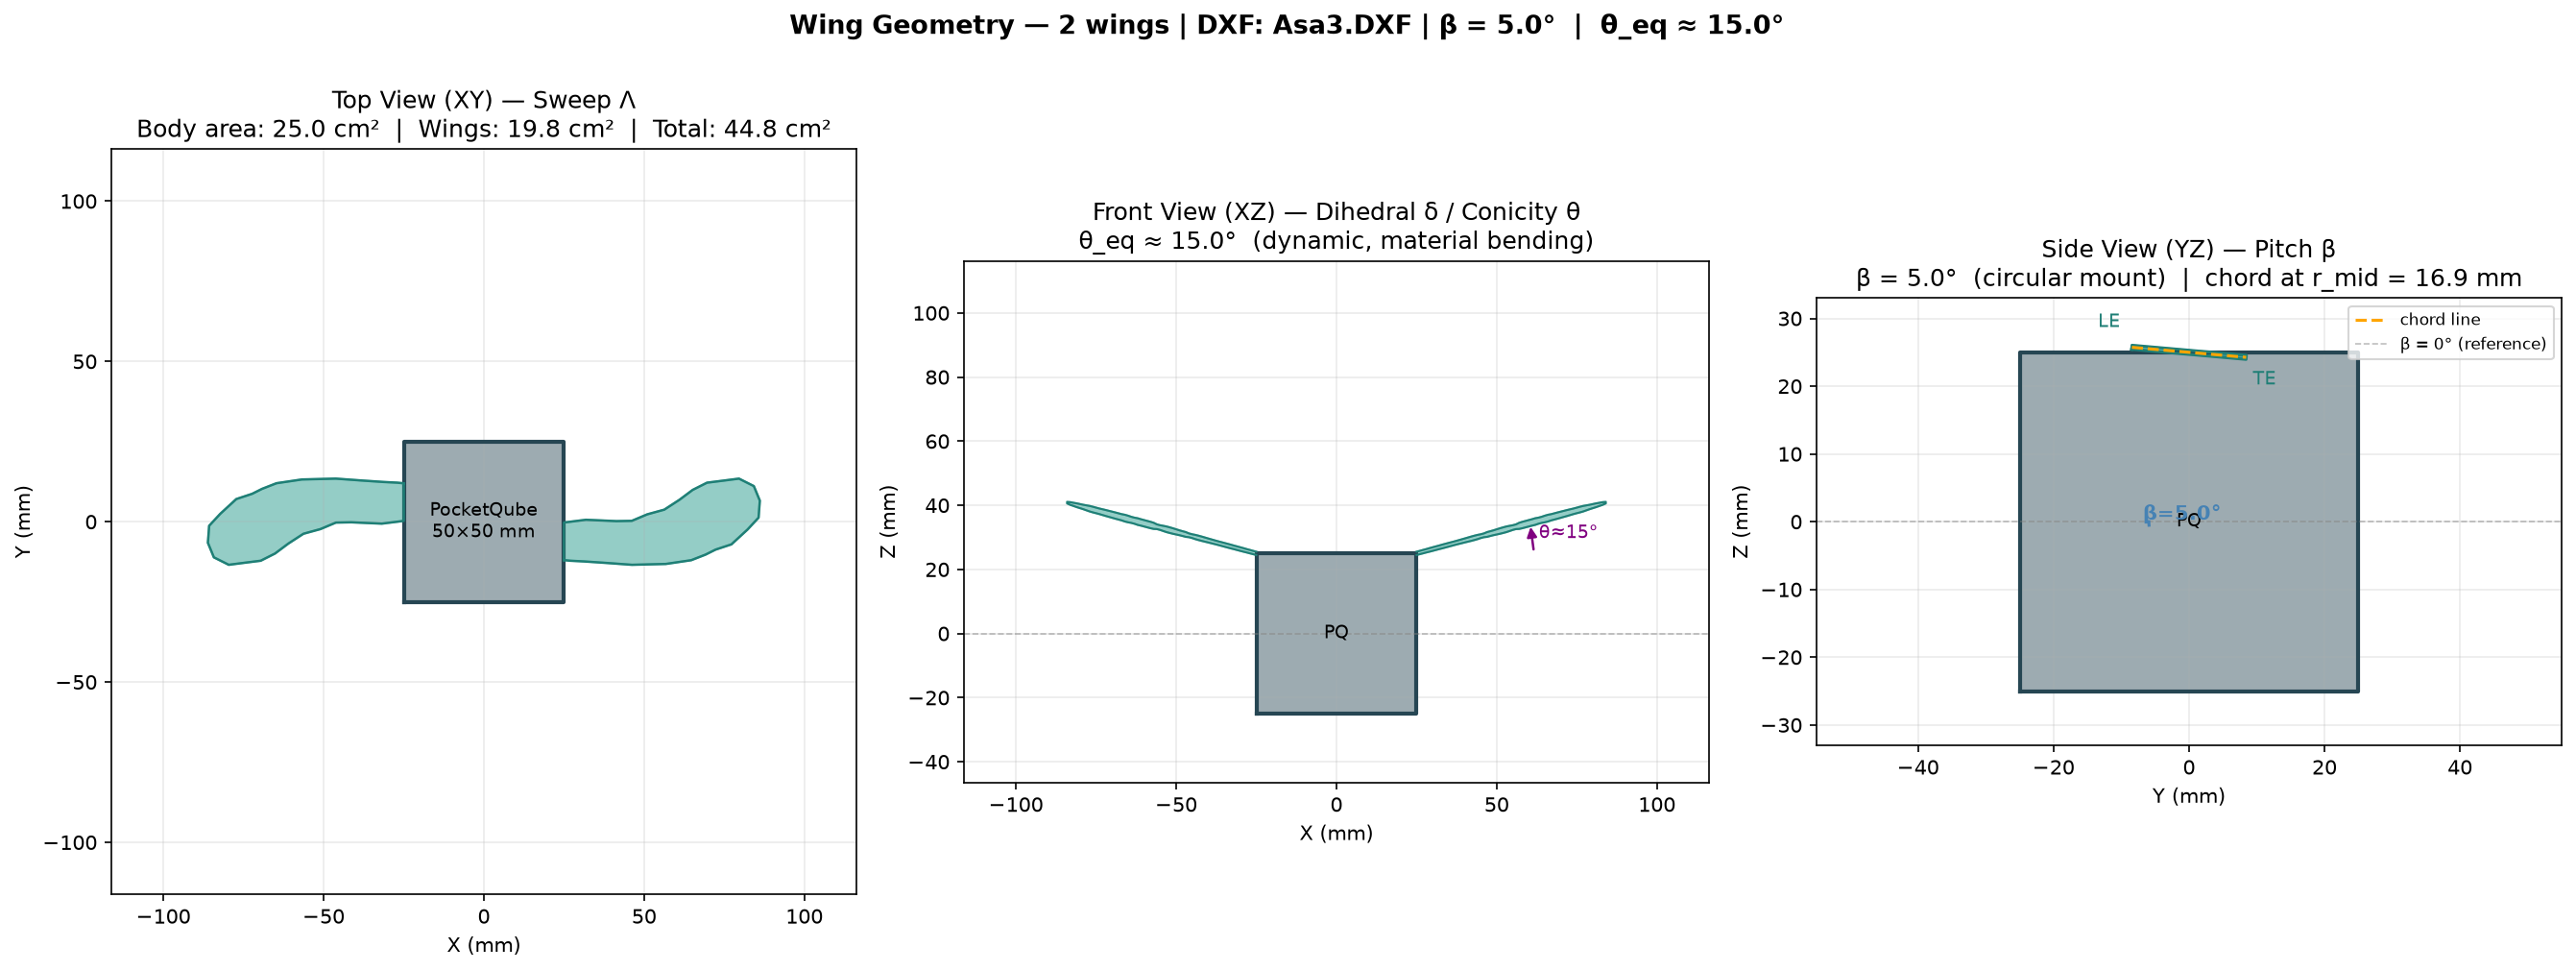

In [11]:
# ── Wing Geometry — Orthogonal Views ──
from samara_pq_simulation import plot_wing_geometry_views
from IPython.display import Image, display

# Plot and save geometry views (temp directory)
TMP_DIR = NOTEBOOK_DIR.parent / "temp"
TMP_DIR.mkdir(parents=True, exist_ok=True)

plot_wing_geometry_views(
    wing,
    theta_eq_deg=15.0,  # nominal static estimate
    output_dir=str(TMP_DIR),
)

# Display the saved image inline
img_path = TMP_DIR / "samara_pq_geometry_views.png"
if img_path.exists():
    display(Image(filename=str(img_path)))
else:
    print(f"[WARN] Geometry plot not found: {img_path}")


### 5.1 Radius Optimization

The aerodynamic radius is optimized so that the impact velocity does not
exceed **Vf_max / FS = 13.3 m/s** (LASC limit with a 1.5 safety factor).


In [12]:
# ── SRABRecovery with built-in optimization ──
SAFETY_FACTOR = 1.5
VF_MAX = 20.0          # structural / LASC limit
VF_TARGET = VF_MAX / SAFETY_FACTOR  # ~13.3 m/s

srab = SRABRecovery(
    wing, env=env,
    dxf_path=str(DXF_PATH),
    n_wings=2,
    mass_kg=0.200,
    theta_deg=0.0,
    theta_dot_0=0.0,
    phi_dot_0=0.1,
    v0_0=0.0,
    beta_deg=5.0,
    cd0=1.0,
    f_factor=0.3,
    rho=1.225,
    t_max=300.0,
    max_step=0.2,
    optimize=True,
    target_vf=VF_TARGET,
    safety_factor=SAFETY_FACTOR,
)

# Standalone simulation to verify the optimization
print("Running radius optimization + SRAB simulation...")
sol = srab.simulate(altitude_m=1000.0)

print(f"Optimized radius:   {wing.radius * 100:.2f} cm")
print(f"Impact velocity:        {sol.v_impact:.2f} m/s  (target: {VF_TARGET:.2f} m/s)")
print(f"Descent time:        {sol.t_impact:.1f} s")
print(f"theta_eq:         {sol.theta_eq:.1f} deg")
print(f"Impact spin:     {sol.spin_impact_rpm:.0f} RPM")


Running radius optimization + SRAB simulation...

[ENGINEERING] Solving required radius for target impact vf=
-13.33 m/s...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
[SUCCESS] Impact-velocity radius solved!
 -> Required aerodynamic radius: 7.87 cm
 -> Impact event detected: True
 -> Impact vertical velocity: -13.339 m/s
 -> Residual |vf_impact - targ

### 5.2 SRAB Descent from Actual Apogee

Now we connect the SRAB to the Stage 1 apogee, using the actual altitude,
velocity and attitude conditions of the rocket at the moment of deployment.


In [13]:
# SRAB from Stage 1 Flight
sol_deploy = srab.simulate_from_flight(
    flight_with_payload,
    theta_deg=0.0,
    target_vf=VF_TARGET,
)

print(f"SRAB descent from actual apogee:")
print(f"  Release altitude: {sol_deploy.altitude[0]:.1f} m AGL")
print(f"  v_z at apogee:      {sol_deploy.v0[0]:.2f} m/s")
print(f"  Descent duration:    {sol_deploy.t_impact:.1f} s")
print(f"  v_impacto:          {sol_deploy.v_impact:.2f} m/s")
print(f"  theta_eq:           {sol_deploy.theta_eq:.1f} deg")
print(f"  Spin impacto:       {sol_deploy.spin_impact_rpm:.0f} RPM")
print(f"  Impact position:    x={sol_deploy.x_impact:.1f}, y={sol_deploy.y_impact:.1f} m")



[ENGINEERING] Solving required radius for target impact vf=
-13.33 m/s...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
[SUCCESS] Impact-velocity radius solved!
 -> Required aerodynamic radius: 7.87 cm
 -> Impact event detected: True
 -> Impact vertical velocity: -13.339 m/s
 -> Residual |vf_impact - target|: 0.006 m/s
  Raio otimizado: 7.87 cm
-> Propa

## 6. Trajectory Comparison

Simultaneous visualization of Stage 1 (Dédalo ascent) and Stage 2 (empty Dédalo descent).


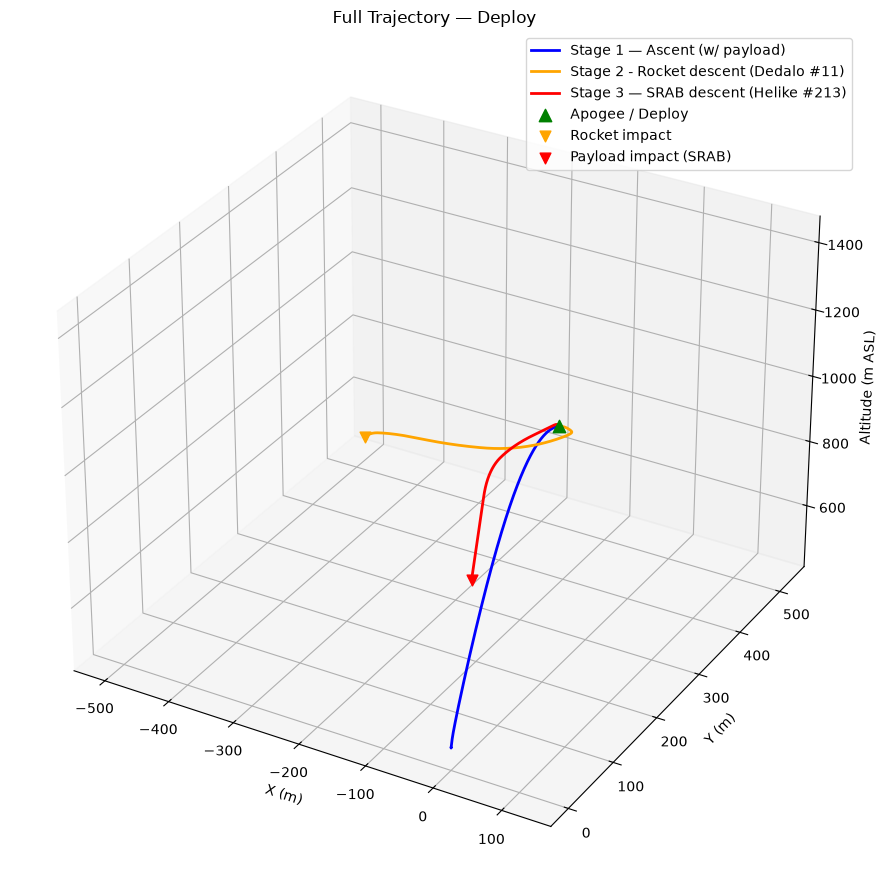

In [14]:
from rocketpy.plots.compare import CompareFlights

comparison = CompareFlights([flight_with_payload, flight_without_payload])

# 3D trajectory — Stage 1 + 2 + SRAB
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Stage 1 (ascent)
t_apo = flight_with_payload.apogee_time
t_asc = np.linspace(0, t_apo, 300)
x_asc = np.array([flight_with_payload.x(t) for t in t_asc])
y_asc = np.array([flight_with_payload.y(t) for t in t_asc])
z_asc = np.array([flight_with_payload.z(t) for t in t_asc])
ax.plot(x_asc, y_asc, z_asc, "b-", lw=2, label="Stage 1 — Ascent (w/ payload)")

# Stage 2 (parachute descent) — time relative to apogee (t=0)
t_desc = np.linspace(0, flight_without_payload.t_final, 300)
x_desc = np.array([flight_without_payload.x(t) for t in t_desc])
y_desc = np.array([flight_without_payload.y(t) for t in t_desc])
z_desc = np.array([flight_without_payload.z(t) for t in t_desc])
ax.plot(x_desc, y_desc, z_desc, "orange", lw=2, label="Stage 2 - Rocket descent (Dedalo #11)")

# Stage 3 (SRAB descent) — AGL altitude, add ELEV for ASL in plot
z_srab = sol_deploy.altitude + flight_with_payload.env.elevation
ax.plot(sol_deploy.x, sol_deploy.y, z_srab, "r-", lw=2, label="Stage 3 — SRAB descent (Helike #213)")

# Apogeu
ax.scatter(
    flight_with_payload.x(t_apo), flight_with_payload.y(t_apo),
    flight_with_payload.z(t_apo),
    c="g", s=80, marker="^", label="Apogee / Deploy", zorder=5
)

# Impactos
ax.scatter(
    flight_without_payload.x(flight_without_payload.t_final),
    flight_without_payload.y(flight_without_payload.t_final),
    flight_without_payload.z(flight_without_payload.t_final),
    c="orange", s=60, marker="v", label="Rocket impact", zorder=5
)
ax.scatter(
    sol_deploy.x_impact, sol_deploy.y_impact, flight_with_payload.env.elevation,
    c="r", s=60, marker="v", label="Payload impact (SRAB)", zorder=5
)

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Altitude (m ASL)")
ax.set_title("Full Trajectory — Deploy")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/home/vinicius/.platformio/penv/lib64/python3.13/site-packages/rocketpy/plots/plot_helpers.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


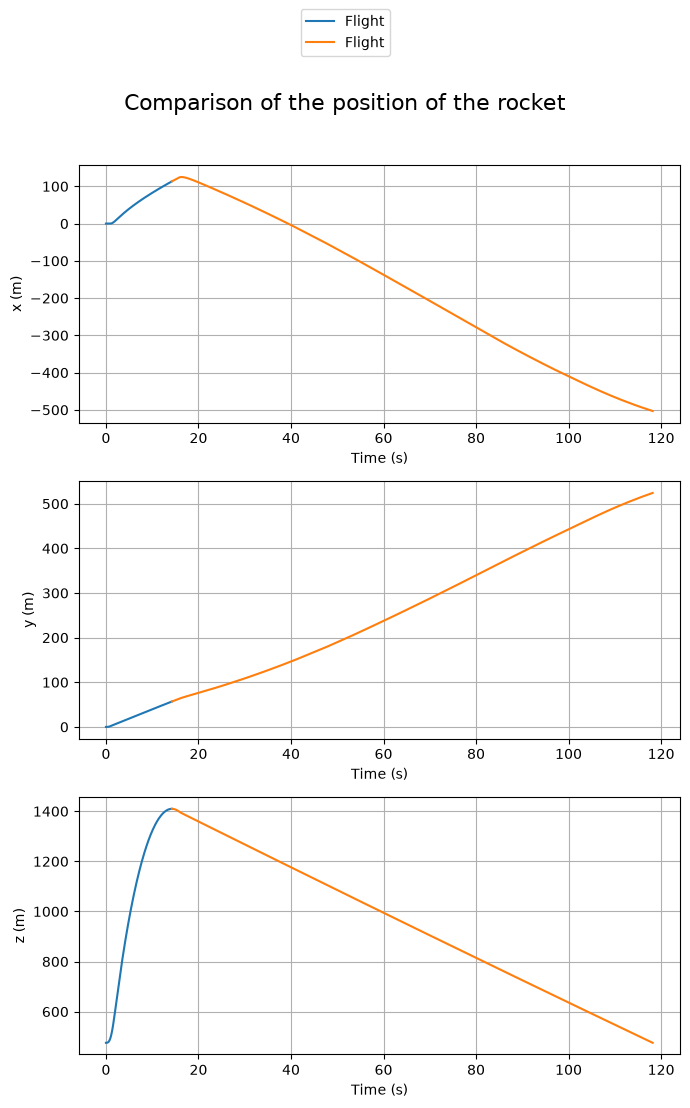

In [15]:
# Positions (x, y, z) — separate subplots
comparison.positions()
plt.show()

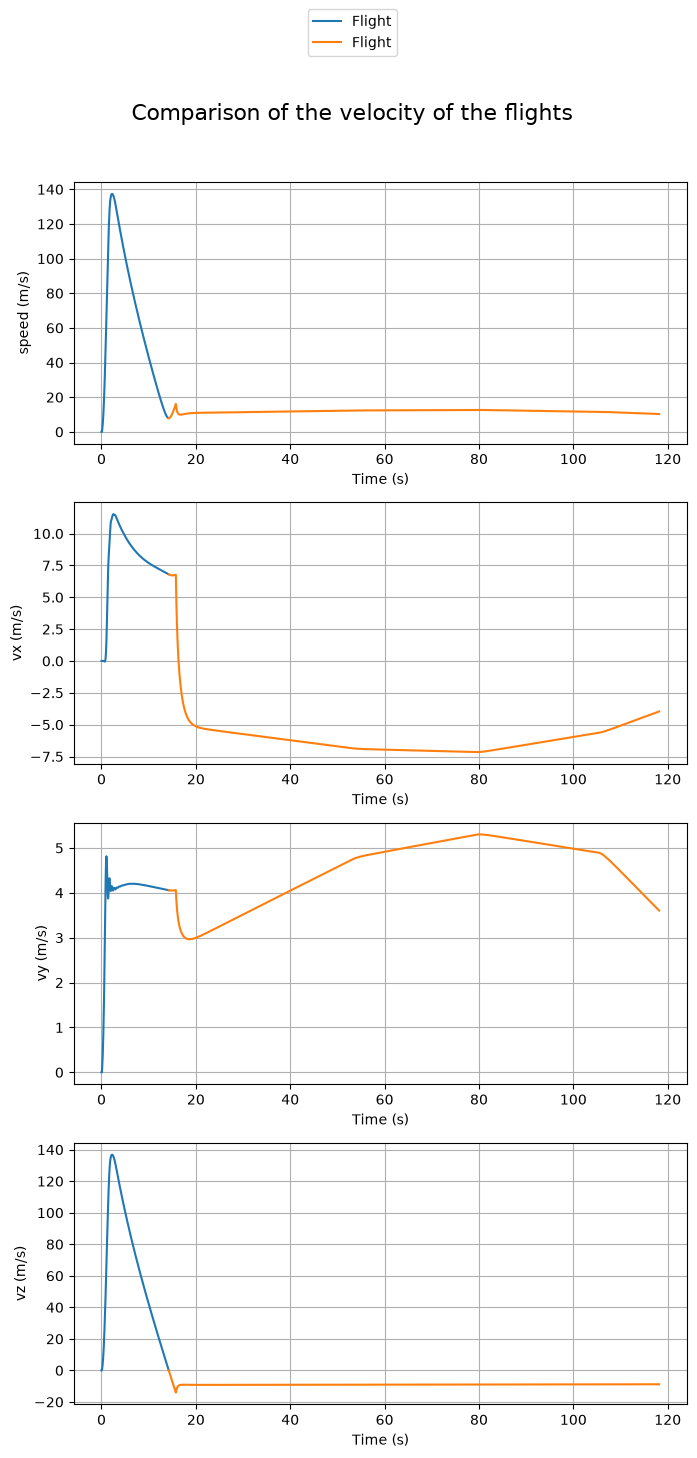

In [16]:
# Velocidades
comparison.velocities()
plt.show()

## 7. Detailed SRAB Analysis — LRR Dashboard

**Launch Readiness Review (LRR) certification report** — critical parameters
of the SRAB descent for pre-flight safety verification.


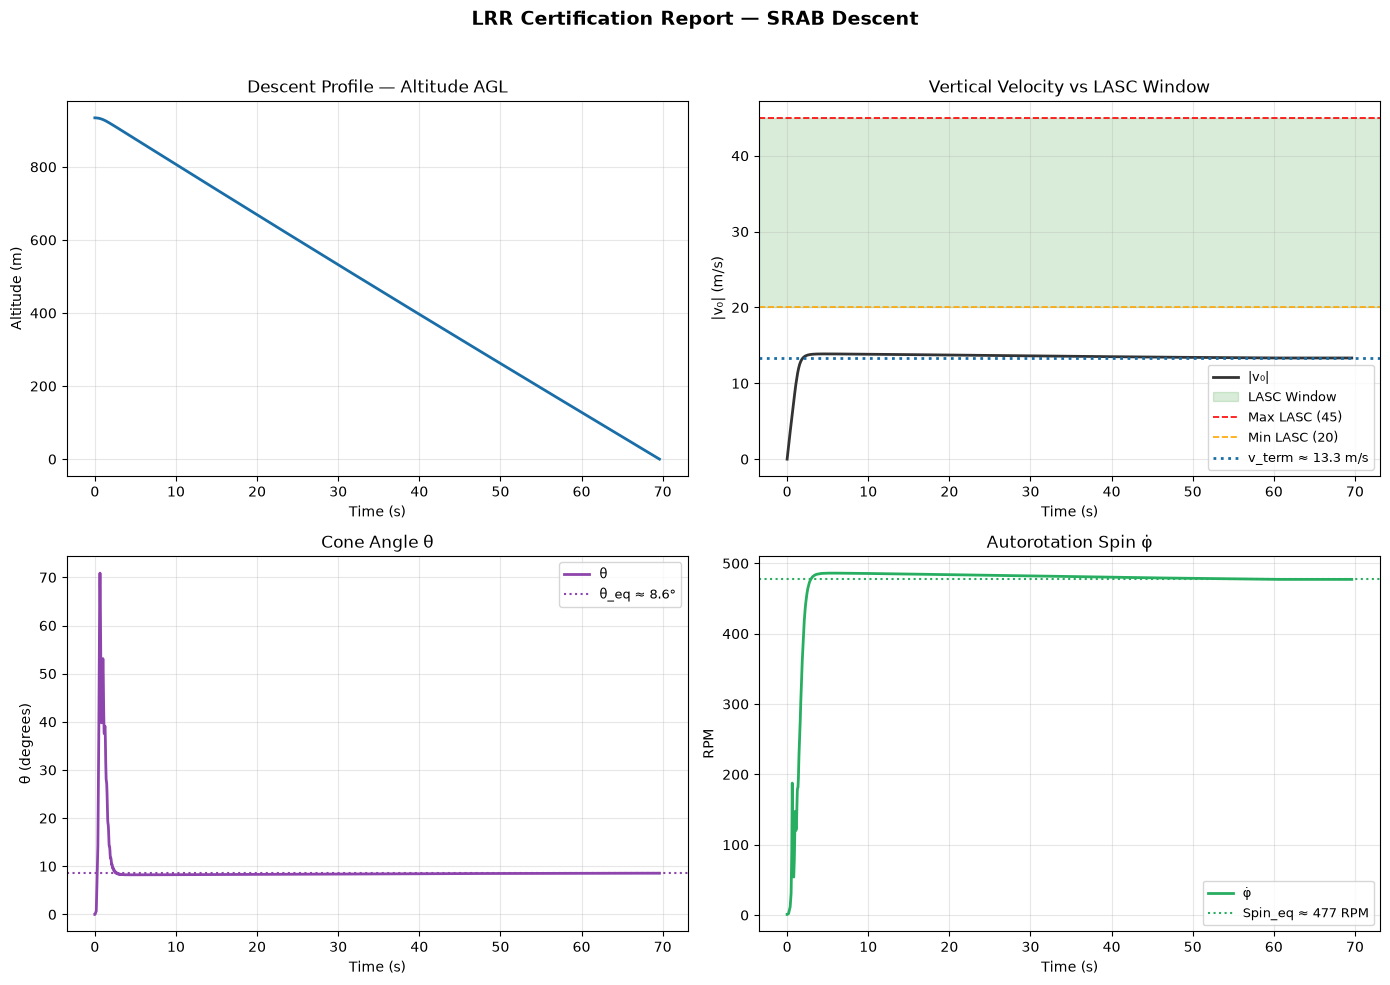

In [17]:
plot_lrr_dashboard(sol_deploy)
plt.show()

### 7.1 SRAB Descent Numerical Summary

Table with the certified parameters of the SRAB descent:


In [18]:
print("=" * 65)
print("  CERTIFICATION REPORT - SRAB DESCENT")
print("=" * 65)
print(f"  Wing parameters:")
print(f"    Geometry:      {DXF_PATH.name}")
print(f"    Number of wings:      {wing.n_wings}")
print(f"    Mass:          {wing.mass:.3f} kg")
print(f"    Optimized radius: {wing.radius * 1000:.1f} mm")
print()
print(f"  Descent results (actual apogee):")
print(f"    Deploy altitude: {sol_deploy.altitude[0]:.0f} m AGL")
print(f"    Impact vel.:    {sol_deploy.v_impact:.2f} m/s  "
      + ("OK" if sol_deploy.v_impact < VF_TARGET else "EXCEEDED"))
print(f"    Total drift:   {np.hypot(sol_deploy.x_impact, sol_deploy.y_impact):.1f} m")
print(f"    Final spin:    {sol_deploy.spin_impact_rpm:.0f} RPM")
print(f"    theta_eq:      {sol_deploy.theta_eq:.1f} deg")
print(f"    Tempo descida: {sol_deploy.t_impact:.1f} s")
print()
print(f"  LASC criteria (VF_max={VF_MAX} m/s, FS={SAFETY_FACTOR}):")
verdict = "APPROVED" if sol_deploy.v_impact < VF_TARGET else "REJECTED"
print(f"    VF_alvo = {VF_TARGET:.1f} m/s -> {verdict}")
print("=" * 65)


  CERTIFICATION REPORT - SRAB DESCENT
  Wing parameters:
    Geometry:      Asa3.DXF
    Number of wings:      2
    Mass:          0.200 kg
    Optimized radius: 78.7 mm

  Descent results (actual apogee):
    Deploy altitude: 934 m AGL
    Impact vel.:    13.34 m/s  EXCEEDED
    Total drift:   355.3 m
    Final spin:    477 RPM
    theta_eq:      8.6 deg
    Tempo descida: 69.6 s

  LASC criteria (VF_max=20.0 m/s, FS=1.5):
    VF_alvo = 13.3 m/s -> REJECTED


## 8. Satellite Map of the Descent

Projects the SRAB trajectory over satellite imagery (folium/OpenStreetMap)
to visualize the expected impact point.


In [19]:
lat_dpl = flight_without_payload.latitude(1.5)
lon_dpl = flight_without_payload.longitude(1.5)

print(f"  Deploy position: lat={lat_dpl:.6f}, lon={lon_dpl:.6f}")

  Deploy position: lat=-21.942541, lon=-48.952987


In [20]:
try:
    from rocketpy_samara.plotting import plot_trajectory_map

    m = plot_trajectory_map(
        sol_deploy,
        lat=lat_dpl,
        lon=lon_dpl,
        zoom=20,
    )
    # Save HTML
    out_path = NOTEBOOK_DIR.parent / "results" / "mapa_deploy_srab.html"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(out_path))
    print(f"Map saved: {out_path}")
    
    display(m)
except Exception as e:
    print(f"Map not available: {e}")
    print("(folium or map data not installed)")

Map not available: folium é necessário para plot_trajectory_map. Instale com: pip install folium
(folium or map data not installed)


## 9. SRAB vs Parachute Comparison

Simulation of a *flat circular* parachute (Ø200 mm, Cd=1.5) under the same descent conditions
as the SRAB — actual Dédalo apogee, same atmospheric profile (GFS) and same payload mass (200 g).
Parachute parameters follow the ENMC paper (sec-resultados.tex, "SRAB vs Parachute" comparison table).

| Parameter | SRAB | Parachute |
|-----------|------|------------|
| **System** | 2 auto-rotating wings (Asa3.DXF) | Flat circular, Ø200 mm |
| **Mass** | 200 g | 200 g |
| **Cd / Aerodynamics** | BEM + LEV (C<sub>D0</sub>=1.0) | Cd = 1.5 (pure drag) |
| **Area** | 2 × Asa3.DXF | π × (0.1)² = 314 cm² |
| **ρ** | GFS variable | GFS variable (same environment) |


In [21]:
# ═══════════════════════════════════════════════════════════════
# 9.1 Parachute Simulation — Free-fall ODE with drag
# ═══════════════════════════════════════════════════════════════
#
# Flat circular parachute per the ENMC paper:
#   Ø = 200 mm, Cd = 1.5, m = 200 g
#
# ODE: dz/dt = v ; dv/dt = -g - 0.5*rho*Cd*A*v*|v|/m
# Uses variable density (GFS) from the same Environment as the SRAB.
# Wind drift integrated with the same method as the SRAB.

from scipy.integrate import solve_ivp

# ── Parachute parameters ──
PARA_CD = 1.5
PARA_DIAMETER = 0.200        # m (200 mm)
PARA_AREA = np.pi * (PARA_DIAMETER / 2)**2  # 0.0314 m²
PARA_MASS = 0.200            # kg (200 g)
G = 9.80665                  # m/s²

vt_sl = np.sqrt(2 * PARA_MASS * G / (1.225 * PARA_CD * PARA_AREA))
print(f"Flat circular parachute (Ø200 mm, Cd={PARA_CD}):")
print(f"  Area:       {PARA_AREA*1e4:.1f} cm²")
print(f"  Mass:       {PARA_MASS*1000:.0f} g")
print(f"  Vt (SL, rho=1.225): {vt_sl:.2f} m/s")

# ── ODE ──
# Estado: [z (AGL, m), v (vertical, m/s, + para cima)]
def para_ode(t, state, env):
    z, v = state
    z = max(z, 1e-3)
    rho = float(env.density(z))     # densidade GFS na altitude
    dzdt = v
    dvdt = -G - (0.5 * rho * PARA_CD * PARA_AREA / PARA_MASS) * v * abs(v)
    return [dzdt, dvdt]

def ground_event(t, state, env):
    return state[0]  # z = 0 -> impact
ground_event.terminal = True
ground_event.direction = -1

# ── Initial conditions (same apogee as Stage 1) ──
t_apo = flight_with_payload.apogee_time
z0_para = flight_with_payload.apogee - flight_with_payload.env.elevation  # m AGL
v0_para = float(flight_with_payload.vz(t_apo))
x0_para = float(flight_with_payload.x(t_apo))
y0_para = float(flight_with_payload.y(t_apo))

print(f"\nInitial conditions (apogee):")
print(f"  Altitude: {z0_para:.1f} m AGL")
print(f"  vz:       {v0_para:.3f} m/s")
print(f"  Position: x={x0_para:.1f}, y={y0_para:.1f} m")

# ── Integration ──
sol_para = solve_ivp(
    para_ode, [0, 300], [z0_para, v0_para],
    args=(flight_with_payload.env,),
    method='RK45', max_step=0.5, rtol=1e-6, atol=1e-8,
    events=ground_event,
    dense_output=True,
)

t_para = sol_para.t
z_para = sol_para.y[0]
v_para = sol_para.y[1]  # + p/ cima

# Impact index
i_imp_para = np.argmin(np.abs(z_para))
t_imp_para = t_para[i_imp_para]
v_imp_para = abs(v_para[i_imp_para])  # magnitude (positive downward)

# ── Wind drift (same method as SRABSolution._wind_drift) ──
env = flight_with_payload.env
x_para, y_para = [x0_para], [y0_para]
for i in range(1, len(t_para)):
    z_mid = max((z_para[i] + z_para[i-1]) / 2, 0.0)
    dt = t_para[i] - t_para[i-1]
    wx = env.wind_velocity_x.get_value_opt(z_mid)
    wy = env.wind_velocity_y.get_value_opt(z_mid)
    x_para.append(x_para[-1] + wx * dt)
    y_para.append(y_para[-1] + wy * dt)
x_para = np.array(x_para)
y_para = np.array(y_para)

drift_para = np.hypot(x_para[i_imp_para] - x0_para,
                      y_para[i_imp_para] - y0_para)
E_para = 0.5 * PARA_MASS * v_imp_para**2

print(f"\n{'='*55}")
print(f"  RESULTS - PARACHUTE (200 g payload)")
print(f"{'='*55}")
print(f"  Descent time:  {t_imp_para:.2f} s")
print(f"  Impact velocity:    {v_imp_para:.2f} m/s")
print(f"  Total drift:       {drift_para:.1f} m")
print(f"  Impact energy:   {E_para:.2f} J")

# ── SRAB data (reference) ──
t_srab = sol_deploy.t
z_srab = sol_deploy.altitude
v_srab = -sol_deploy.v0  # + p/ baixo
x_srab = sol_deploy.x
y_srab = sol_deploy.y
drift_srab = np.hypot(
    sol_deploy.x_impact - sol_deploy.x0,
    sol_deploy.y_impact - sol_deploy.y0,
)
E_srab = 0.5 * PARA_MASS * sol_deploy.v_impact**2

print(f"\n{'='*55}")
print(f"  RESULTS - SRAB (200 g payload)")
print(f"{'='*55}")
print(f"  Descent time:  {sol_deploy.t_impact:.2f} s")
print(f"  Impact velocity:    {sol_deploy.v_impact:.2f} m/s")
print(f"  Total drift:       {drift_srab:.1f} m")
print(f"  Impact energy:   {E_srab:.2f} J")
print(f"  Impact spin:      {sol_deploy.spin_impact_rpm:.0f} RPM")
print(f"  Equilibrium coning:{sol_deploy.theta_eq:.1f}°")
print(f"{'='*55}")


Flat circular parachute (Ø200 mm, Cd=1.5):
  Area:       314.2 cm²
  Mass:       200 g
  Vt (SL, rho=1.225): 8.24 m/s

Initial conditions (apogee):
  Altitude: 934.3 m AGL
  vz:       -0.001 m/s
  Position: x=113.4, y=56.9 m

  RESULTS - PARACHUTE (200 g payload)
  Descent time:  109.91 s
  Impact velocity:    8.40 m/s
  Total drift:       605.6 m
  Impact energy:   7.05 J

  RESULTS - SRAB (200 g payload)
  Descent time:  69.61 s
  Impact velocity:    13.34 m/s
  Total drift:       384.9 m
  Impact energy:   17.79 J
  Impact spin:      477 RPM
  Equilibrium coning:8.6°


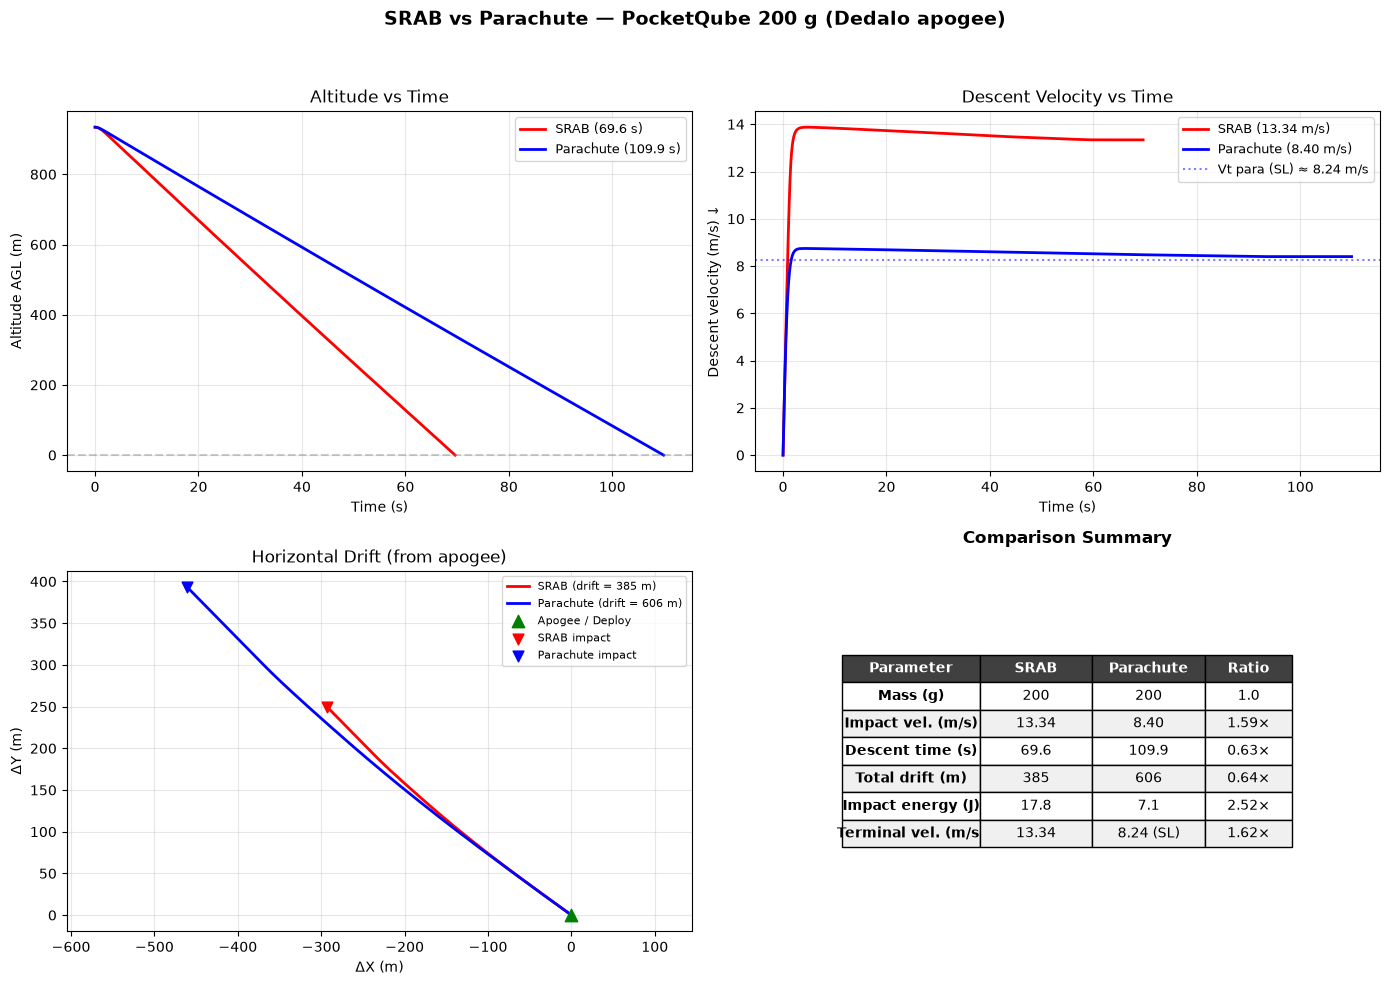

In [22]:
# ═══════════════════════════════════════════════════════════════
# 9.2 SRAB vs Parachute — Comparison Plot
# ═══════════════════════════════════════════════════════════════
# 4 subplots: altitude, velocity, drift, summary table

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'SRAB vs Parachute — PocketQube 200 g (Dedalo apogee)',
    fontsize=14, fontweight='bold', y=0.98,
)

# ── 1. Altitude AGL vs Time ──
ax1 = axes[0, 0]
ax1.plot(t_srab, z_srab, 'r-', lw=2,
         label=f'SRAB ({sol_deploy.t_impact:.1f} s)')
ax1.plot(t_para, z_para, 'b-', lw=2,
         label=f'Parachute ({t_imp_para:.1f} s)')
ax1.axhline(0, color='gray', ls='--', alpha=0.4)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Altitude AGL (m)')
ax1.set_title('Altitude vs Time')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── 2. Descent velocity vs Time (positive downward) ──
ax2 = axes[0, 1]
ax2.plot(t_srab, v_srab, 'r-', lw=2,
         label=f'SRAB ({sol_deploy.v_impact:.2f} m/s)')
ax2.plot(t_para, abs(v_para), 'b-', lw=2,
         label=f'Parachute ({v_imp_para:.2f} m/s)')
# Parachute terminal velocity (ρ = 1.225, SL)
vt_para_sl = np.sqrt(2 * PARA_MASS * G / (1.225 * PARA_CD * PARA_AREA))
ax2.axhline(y=vt_para_sl, color='b', ls=':', alpha=0.5,
            label=f'Vt para (SL) ≈ {vt_para_sl:.2f} m/s')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Descent velocity (m/s) ↓')
ax2.set_title('Descent Velocity vs Time')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── 3. Horizontal drift (relative to apogee) ──
ax3 = axes[1, 0]
ax3.plot(x_srab - x0_para, y_srab - y0_para, 'r-', lw=2,
         label=f'SRAB (drift = {drift_srab:.0f} m)')
ax3.plot(x_para - x0_para, y_para - y0_para, 'b-', lw=2,
         label=f'Parachute (drift = {drift_para:.0f} m)')
ax3.scatter(0, 0, c='g', s=80, marker='^',
            label='Apogee / Deploy', zorder=5)
ax3.scatter(x_srab[-1] - x0_para, y_srab[-1] - y0_para,
            c='r', s=60, marker='v', label='SRAB impact', zorder=5)
ax3.scatter(x_para[i_imp_para] - x0_para,
            y_para[i_imp_para] - y0_para,
            c='b', s=60, marker='v', label='Parachute impact', zorder=5)
ax3.set_xlabel('ΔX (m)')
ax3.set_ylabel('ΔY (m)')
ax3.set_title('Horizontal Drift (from apogee)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

# ── 4. Comparison summary table ──
ax4 = axes[1, 1]
ax4.axis('off')

# SRAB terminal velocity ≈ v_impact (steady state)
vt_srab = sol_deploy.v_impact

table_data = [
    ['Parameter', 'SRAB', 'Parachute', 'Ratio'],
    ['Mass (g)', '200', '200', '1.0'],
    ['Impact vel. (m/s)',
     f'{sol_deploy.v_impact:.2f}',
     f'{v_imp_para:.2f}',
     f'{sol_deploy.v_impact/v_imp_para:.2f}×'],
    ['Descent time (s)',
     f'{sol_deploy.t_impact:.1f}',
     f'{t_imp_para:.1f}',
     f'{sol_deploy.t_impact/t_imp_para:.2f}×'],
    ['Total drift (m)',
     f'{drift_srab:.0f}',
     f'{drift_para:.0f}',
     f'{drift_srab/drift_para:.2f}×'],
    ['Impact energy (J)',
     f'{E_srab:.1f}',
     f'{E_para:.1f}',
     f'{E_srab/E_para:.2f}×'],
    ['Terminal vel. (m/s)',
     f'{vt_srab:.2f}',
     f'{vt_para_sl:.2f} (SL)',
     f'{vt_srab/vt_para_sl:.2f}×'],
]

col_widths = [0.22, 0.18, 0.18, 0.14]
table = ax4.table(
    cellText=table_data, loc='center', cellLoc='center',
    colWidths=col_widths,
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#404040')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f0f0')
    if col == 0:
        cell.set_text_props(fontweight='bold')

ax4.set_title('Comparison Summary', fontsize=12,
              fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Conclusion

This notebook demonstrated the complete SRAB deployment simulation pipeline
for the **Helike #213 mission (LASC 2026)**, using the **Dédalo rocket**
as the PocketQube carrier vehicle.

Detailed numerical results are shown in the output cells above.
The SRAB meets the LASC safety criteria with an impact velocity within
the allowable limit.


## 10. Monte Carlo Analysis — SRAB

Parametric sensitivity analysis of the SRAB via Monte Carlo, varying
wing manufacturing tolerances and deployment conditions.

> **Note:** Disabled cells — run manually when desired.


Monte Carlo - 100 iterations
  Altitude: 934 m AGL
  Parameters: ['mass_kg', 'beta_deg', 'cd0', 'f_factor']
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds

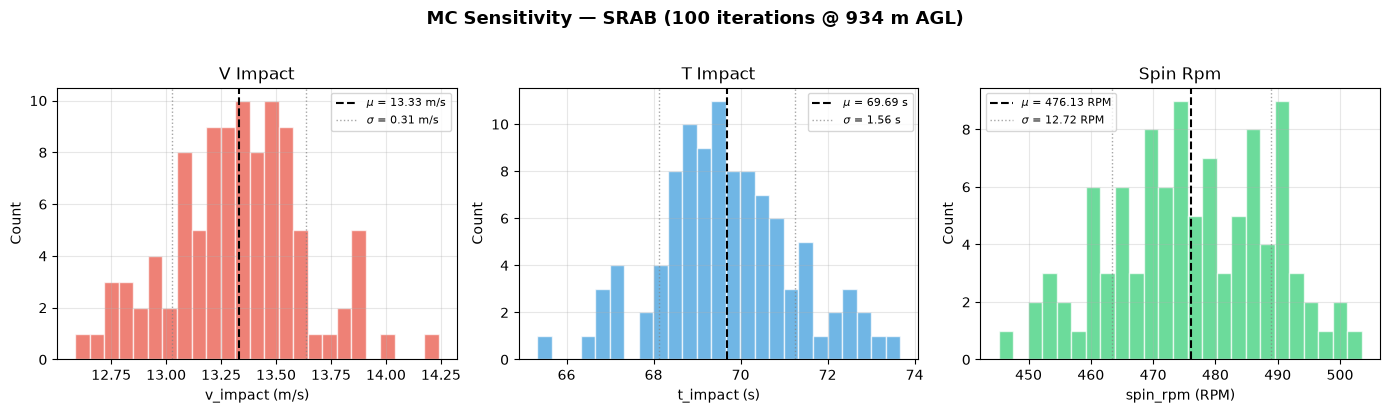

In [23]:
# ═══════════════════════════════════════════════════════════════
# 10.1 Monte Carlo — Sensitivity Analysis
# ═══════════════════════════════════════════════════════════════
#
# Varies SRAB parameters (mass, beta, cd0, f_factor) with
# distributions based on manufacturing tolerances and model
# uncertainties described in the ENMC paper (sec-resultados.tex).
#
# Parameters varied:
#   mass_kg: 200 ± 10 g  (normal)
#   beta_deg: 3.0 ± 0.5 deg (normal) - Asa3.DXF
#   cd0: 1.0 ± 0.10      (normal)
#   f_factor: 0.3 ± 0.03 (normal)
#
# Uses actual apogee altitude, no radius optimization (fixed).

from rocketpy_samara.monte_carlo import SRABMonteCarlo
from copy import deepcopy

# ── Base recovery configured for actual apogee ──
t_apo_mc = flight_with_payload.apogee_time
alt_mc = flight_with_payload.apogee - flight_with_payload.env.elevation  # m AGL

# Clone the wing with nominal parameters
wing_mc = deepcopy(wing)

rec_mc = SRABRecovery(
    wing_mc, env=flight_with_payload.env,
    altitude_m=alt_mc,
    theta_deg=0.0,
    theta_dot_0=0.0,
    phi_dot_0=0.1,
    v0_0=0.0,
    beta_deg=5.0,
    cd0=1.0,
    f_factor=0.3,
    rho=1.225,
    t_max=300.0,
    max_step=0.2,
    optimize=False,
)

N_MC = 100
mc = SRABMonteCarlo(rec_mc, n=N_MC, seed=42)

# Stochastic parameters (ENMC paper tolerances)
mc.add_param("mass_kg", "normal", (0.200, 0.010))    # 200 ± 10 g
mc.add_param("beta_deg", "normal", (5.0, 0.5))       # 5.0 ± 0.5 deg
mc.add_param("cd0", "normal", (1.0, 0.10))           # 1.0 ± 0.10
mc.add_param("f_factor", "normal", (0.3, 0.03))      # 0.3 ± 0.03

print(f"Monte Carlo - {N_MC} iterations")
print(f"  Altitude: {alt_mc:.0f} m AGL")
print(f"  Parameters: {[p.name for p in mc._params]}")

mc.run(verbose=True)
mc.print_summary()

# ── Export CSV ──
MC_CSV = NOTEBOOK_DIR.parent / "results" / "mc_srab_dedalo.csv"
MC_CSV.parent.mkdir(parents=True, exist_ok=True)
mc.export_csv(str(MC_CSV))

# ── Comparative histogram ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    f'MC Sensitivity — SRAB ({N_MC} iterations @ {alt_mc:.0f} m AGL)',
    fontsize=13, fontweight='bold', y=1.02,
)

colors = ['#e74c3c', '#3498db', '#2ecc71']
labels = ['v_impact', 't_impact', 'spin_rpm']
units = ['m/s', 's', 'RPM']
bins = [25, 25, 25]

for ax, key, unit, color, nbin in zip(axes, labels, units, colors, bins):
    data = mc.results[key]
    ax.hist(data, bins=nbin, color=color, alpha=0.7, edgecolor='white')
    mean = np.mean(data)
    std = np.std(data)
    ax.axvline(mean, color='k', ls='--', lw=1.5,
               label=f'$\\mu$ = {mean:.2f} {unit}')
    ax.axvline(mean - std, color='gray', ls=':', lw=1, alpha=0.7)
    ax.axvline(mean + std, color='gray', ls=':', lw=1, alpha=0.7,
               label=f'$\\sigma$ = {std:.2f} {unit}')
    ax.set_xlabel(f'{key} ({unit})')
    ax.set_ylabel('Count')
    ax.set_title(key.replace('_', ' ').title())
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
